<a href="https://colab.research.google.com/github/yo-danny/speech-emotion-recognition/blob/main/speech_emotion_recognition_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speech Emotion Recognition



In [1]:
import librosa
import soundfile
import os, glob, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from librosa.feature import spectral_centroid, spectral_rolloff, zero_crossing_rate

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

from keras import Sequential
from keras.layers import Dense, LSTM, Dropout, Activation
from keras.layers import MaxPooling1D, Conv1D
from keras.callbacks import ModelCheckpoint

Defining a function to extract features from the audio.

In [2]:
def extract_feature(file_name, mfcc, chroma, mel, spectral_centroid, spectral_rolloff, zero_crossing_rate):
    with soundfile.SoundFile(file_name) as sound_file:
        X = sound_file.read(dtype="float32")
        sample_rate=sound_file.samplerate
        if chroma:
            stft=np.abs(librosa.stft(X))
        result=np.array([])
        if mfcc: # mapping sound to human perception to identify phonetic content
            mfccs=np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T, axis=0)
            result=np.hstack((result, mfccs))
        if chroma: # analyzing the harmonic and tonal content
            chroma=np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T,axis=0)
            result=np.hstack((result, chroma))
        if mel: # visual representations of audio frequency over time
            mel=np.mean(librosa.feature.melspectrogram(y=X, sr=sample_rate).T,axis=0)
            result=np.hstack((result, mel))
        if spectral_centroid: # tells you where the middle of the frequency spectrum is (the "average" frequency)
            spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=X, sr=sample_rate).T,axis=0)
            result=np.hstack((result, spectral_centroid))
        if spectral_rolloff: # tells you where the edge of the majority of energy lies (usually 95% or 85% of the energy is below this point)
            spectral_rolloff = np.mean(librosa.feature.spectral_rolloff(y=X, sr=sample_rate).T,axis=0)
            result=np.hstack((result, spectral_rolloff))
        if zero_crossing_rate: # counts how often the signal crosses the zero axis, used to distinguish noisy, high-energy emotions
            zero_crossing_rate = np.mean(librosa.feature.zero_crossing_rate(y=X).T,axis=0)
            result=np.hstack((result, zero_crossing_rate))
    return result

Dictionary to hold number values for emotions avaible in the RAVDESS dataset.

In [3]:
emotions = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

observed_emotions=['calm', 'happy', 'fearful', 'disgust']

Function to load the data from our ambient, calls the extraction of features and return the train and test datasets for model training.

In [16]:
def load_data(test_size=0.2):
    x, y = [], []
    for file in glob.glob("/content/drive/MyDrive/speech-emotion-recognition-ravdess-data/Actor_*/*.wav"):
        file_name = os.path.basename(file)
        emotion=emotions[file_name.split("-")[2]]
        if emotion not in observed_emotions:
            continue
        feature = extract_feature(file_name=file, mfcc=True, chroma=True, mel=True, spectral_centroid=True, spectral_rolloff=True, zero_crossing_rate=True)
        x.append(feature)
        y.append(emotion)
    return np.array(np.expand_dims(x, axis=2)), np.array(y)


In [17]:
all_features, all_labels = load_data()

x_train, x_test, y_train, y_test = train_test_split(all_features, all_labels, test_size=0.25, random_state=42, stratify=all_labels)

lb = LabelBinarizer()
y_train_encoded = lb.fit_transform(y_train)
y_test_encoded = lb.transform(y_test)

Initializing the CNN model.

In [21]:
model = Sequential()
model.add(Conv1D(64, 5, padding='same', input_shape=(x_train.shape[1], 1)))
model.add(Activation('relu'))
model.add(MaxPooling1D(pool_size=8))
model.add(Dropout(0.2))
model.add(Conv1D(128, 5, padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling1D(pool_size=8))
model.add(Dropout(0.2))
model.add(LSTM(128))
model.add(Dropout(0.2))
model.add(Dense(len(observed_emotions)))
model.add(Activation('softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 183, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 183, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 22, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,572 (678.02 KB)

 Trainable params: 173,572 (678.02 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(x_train, y_train_encoded, batch_size = 16, epochs=100, validation_data=(x_test, y_test_encoded), callbacks=[early_stopping])

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.3038 - loss: 1.3657 - val_accuracy: 0.3385 - val_loss: 1.2670
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3785 - loss: 1.2779 - val_accuracy: 0.3906 - val_loss: 1.2470
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4323 - loss: 1.2230 - val_accuracy: 0.4219 - val_loss: 1.1916
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4410 - loss: 1.2032 - val_accuracy: 0.3906 - val_loss: 1.2122
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4948 - loss: 1.1499 - val_accuracy: 0.4844 - val_loss: 1.1657
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4722 - loss: 1.1484 - val_accuracy: 0.4583 - val_loss: 1.1542
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4913 - loss: 1.1401 - val_accuracy: 0.4635 - val_loss: 1.1838
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4688 - loss: 1.1546 - val_accuracy: 0.

Predicting and evaluating the model.

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 183, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 183, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 22, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,718 (1.99 MB)

 Trainable params: 173,572 (678.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 347,146 (1.32 MB)

None
Accuracy: 54.17%
Precision: 52.75%
Recall: 54.17%
F1-Score: 52.16%


<Axes: >

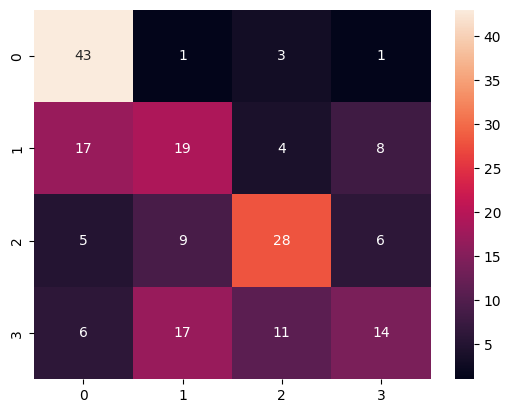

In [23]:
y_pred = model.predict(x_test)

y_pred_encoded = lb.inverse_transform(y_pred)

accuracy=accuracy_score(y_true=y_test, y_pred=y_pred_encoded)
precision=precision_score(y_true=y_test, y_pred=y_pred_encoded, average='macro')
recall=recall_score(y_true=y_test, y_pred=y_pred_encoded, average='macro')
f1=f1_score(y_true=y_test, y_pred=y_pred_encoded, average='macro')

print(model.summary())

print("Accuracy: {:.2f}%".format(accuracy*100))
print("Precision: {:.2f}%".format(precision*100))
print("Recall: {:.2f}%".format(recall*100))
print("F1-Score: {:.2f}%".format(f1*100))

sns.heatmap(confusion_matrix(y_test, y_pred_encoded), annot=True)